In [1]:
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
import os

In [2]:
load_dotenv(override=True)

True

In [3]:
if os.environ.get("GOOGLE_API_KEY") is None:
    raise ValueError("GOOGLE_API_KEY is not set in the environment variables.")
else:
    llm = ChatGoogleGenerativeAI(
        model="gemini-3.5-flash-lite",
        api_key=os.environ.get("GOOGLE_API_KEY")
    )

## Pydantic Schema

In [47]:
from pydantic import BaseModel, Field 

class graph_schema(BaseModel):

    topic: str = Field(description="The topic of the graph") ## user provided topic
    post: str = Field(description="The LinkedIn post content") ## AI generated LinkedIn post content based on the topic
    curated_post: str = Field(description="The curated LinkedIn post content") ## AI generated LinkedIn post content based on the topic, but curated to be more engaging and relevant for the audience
    messages: list = Field(description="A list of messages exchanged during the graph execution") ## A list of messages exchanged during the graph execution

demo_obj = graph_schema(
    topic="Agentic AI and its impact on the future of work",
    post="Agentic AI is transforming the way we work, enabling new levels of productivity and creativity. As we embrace these advancements, it's crucial to consider the ethical implications and ensure that AI is used responsibly.",
    curated_post="Agentic AI is revolutionizing the future of work, unlocking unprecedented productivity and creativity. As we navigate this transformative era, it's essential to address ethical considerations and promote responsible AI usage to ensure a positive impact on society.",
    messages=[
        {"role": "system", "content": "You are a helpful assistant."}]
)
print(demo_obj)

topic='Agentic AI and its impact on the future of work' post="Agentic AI is transforming the way we work, enabling new levels of productivity and creativity. As we embrace these advancements, it's crucial to consider the ethical implications and ensure that AI is used responsibly." curated_post="Agentic AI is revolutionizing the future of work, unlocking unprecedented productivity and creativity. As we navigate this transformative era, it's essential to address ethical considerations and promote responsible AI usage to ensure a positive impact on society." messages=[{'role': 'system', 'content': 'You are a helpful assistant.'}]


In [48]:
## creating a function to generate a LinkedIn post based on the topic provided by the user

from langchain_core.messages import HumanMessage, AIMessage


def generate_linkedin_post(state: graph_schema) -> graph_schema:
    messages = state.messages
    
    prompt = f"Generate a LinkedIn post based on the following topic: {state.topic}. The post should be engaging, informative, and relevant to the audience. Please provide the post content in a concise manner."
    
    ## Adding the user message to the messages list
    Human_message={"role": "user", "content": HumanMessage(content=state.topic)}
    messages.append(Human_message)
    
    
    response = llm.invoke(prompt).text
    
    ## Adding the AI response to the messages list
    AI_message={"role": "assistant", "content": AIMessage(content=response)}
    messages.append(AI_message)
    
    ## Updating the state with the generated post and messages
    state.messages = messages
    # Assuming the response is a string containing the generated post
    state.post = response
    
    return state

In [49]:
## creating a function to curate the LinkedIn post to make it more engaging and relevant for the audience

def curate_linkedin_post(state: graph_schema) -> graph_schema:
    prompt = f"Curate the following LinkedIn post to make it more engaging and relevant for the audience: {state.post}. Please provide the curated post content in a concise manner."
        
    response = llm.invoke(prompt).text
    
    messages = state.messages
    
    ## Adding the AI response to the messages list
    AI_message={"role": "assistant", "content": AIMessage(content=response)}
    messages.append(AI_message)
    
    # Assuming the response is a string containing the curated post
    state.curated_post = response
    state.messages = messages
    
    return state

In [50]:
from langgraph.graph import StateGraph,START,END

graph = StateGraph(graph_schema)
graph.add_node("Generate LinkedIn Post", generate_linkedin_post)
graph.add_node("Curate LinkedIn Post", curate_linkedin_post)

graph.add_edge(START, "Generate LinkedIn Post")
graph.add_edge("Generate LinkedIn Post", "Curate LinkedIn Post")
graph.add_edge("Curate LinkedIn Post", END)


In [51]:
linkedin_post_graph = graph.compile()

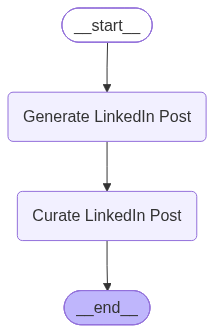

In [52]:
from IPython.display import display, Image

Image(linkedin_post_graph.get_graph().draw_mermaid_png())

In [53]:
linkedin_post_graph.invoke({ "topic": "Agentic AI and its impact on the future of work","post": "","curated_post": "",
                            "messages":[{"role": "system", "content": "You are a helpful assistant."}]})

{'topic': 'Agentic AI and its impact on the future of work',
 'post': '**Say goodbye to copilots. Say hello to agents.** 👋\n\nWe’ve spent the last couple of years getting used to AI as an assistant—writing drafts, summarizing emails, and answering prompts. But the shift to **Agentic AI** is about to completely redefine the future of work. \n\nUnlike traditional AI that simply *reacts* to prompts, Agentic AI can **reason, plan, and execute complex multi-step workflows autonomously.** \n\nInstead of you telling an AI *how* to do every little step, you give it an ultimate goal, and it figures out the rest:\n1️⃣ Analyzes the objective\n2️⃣ Breaks it down into tasks\n3️⃣ Uses tools, loops through revisions, and delivers the final result.\n\n**What does this mean for the future of work?**\n* **From "Doers" to "Directors":** Our roles will shift from executing tedious tasks to orchestrating intelligent agents and setting strategic direction.\n* **Hyper-Productivity:** Workflows that used to t